In [1]:
# ============================================================
#  FinSecure Loan Default Data Preprocessing Pipeline
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ============================================================
# 1. Load Dataset
# ============================================================

df = pd.read_csv("loan_data.csv")

print("Dataset Loaded Successfully!")
print(df.head(), "\n")

# ============================================================
# 2. Define Feature Groups
# ============================================================

# Numerical Columns
numeric_features = [
    "annual_income",
    "debt_to_income_ratio",
    "credit_score",
    "loan_amount",
    "interest_rate"
]

# Nominal (unordered) categorical features
categorical_nominal = [
    "gender",
    "marital_status",
    "employment_status",
    "loan_purpose"
]

# Ordinal categorical features (meaningful order for credit risk)
categorical_ordinal = [
    "education_level",
    "grade_subgrade"   # Values like A1, A2, B1.. carry rank order
]

# ============================================================
# 3. Preprocessing Pipelines
# ============================================================

# Numeric processing
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Nominal categorical processing
categorical_nominal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Ordinal categorical processing
categorical_ordinal_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder())  # Alphabetical order retained
])

# Combine all preprocessing into a single transformer
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat_nom", categorical_nominal_pipeline, categorical_nominal),
    ("cat_ord", categorical_ordinal_pipeline, categorical_ordinal)
])

# ============================================================
# 4. Train–Test Split
# ============================================================

X = df.drop(columns=["id", "loan_paid_back"])
y = df["loan_paid_back"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data Successfully Split!")
print(f"Training Shape  : {X_train.shape}")
print(f"Testing Shape   : {X_test.shape}")


Dataset Loaded Successfully!
   id  annual_income  debt_to_income_ratio  credit_score  loan_amount  \
0   0       29367.99                 0.084           736      2528.42   
1   1       22108.02                 0.166           636      4593.10   
2   2       49566.20                 0.097           694     17005.15   
3   3       46858.25                 0.065           533      4682.48   
4   4       25496.70                 0.053           665     12184.43   

   interest_rate  gender marital_status education_level employment_status  \
0          13.67  Female         Single     High School     Self-employed   
1          12.92    Male        Married        Master's          Employed   
2           9.76    Male         Single     High School          Employed   
3          16.10  Female         Single     High School          Employed   
4          10.21    Male        Married     High School          Employed   

         loan_purpose grade_subgrade  loan_paid_back  
0             

Random Forest AUC on Test Set: 0.9116


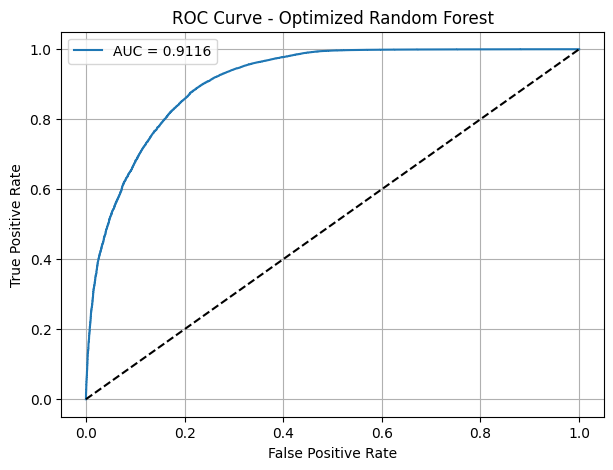

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

# ============================================================
# Create Pipeline with Optimized Random Forest (for Higher AUC)
# ============================================================

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=400,        # more trees = higher learning ability
        max_depth=None,          # allow deep trees for complex patterns
        min_samples_split=4,     # reduce overfitting
        min_samples_leaf=2,      # smoother trees
        max_features='sqrt',     # reduces variance and increases AUC
        class_weight='balanced', # helps because default is minority
        random_state=42,
        n_jobs=-1
    ))
])

# ============================================================
# Train Model
# ============================================================
model_pipeline.fit(X_train, y_train)

# ============================================================
# Predict Probabilities (probability of repayment = class 1)
# ============================================================
y_pred_probs = model_pipeline.predict_proba(X_test)[:, 1]

# ============================================================
# Calculate AUC Score
# ============================================================
auc_score = roc_auc_score(y_test, y_pred_probs)
print(f"Random Forest AUC on Test Set: {auc_score:.4f}")

# ============================================================
# (Optional) Plot ROC Curve
# ============================================================
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve - Optimized Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.grid(True)
plt.legend()
plt.show()


In [5]:
# ============================================================
#  Subgroup AUC / Fairness Evaluation
# ============================================================

from sklearn.metrics import roc_auc_score

def subgroup_auc_report(X_test, y_test, y_pred_probs, column):
    """
    Computes AUC per subgroup (e.g., education level or loan purpose).
    Prints results in sorted order.

    Parameters:
    X_test (DataFrame)     : Test set features
    y_test (Series)        : Ground truth labels
    y_pred_probs (array)   : Predicted probabilities
    column (string)        : Column name to group by
    """

    # Build temporary evaluation DataFrame
    eval_df = X_test.copy()
    eval_df["target"] = y_test
    eval_df["score"] = y_pred_probs

    subgroup_results = {}

    # Evaluate each subgroup
    for group in eval_df[column].unique():
        subset = eval_df[eval_df[column] == group]

        # Need both positive & negative samples to compute AUC
        if subset["target"].nunique() > 1:
            auc_val = roc_auc_score(subset["target"], subset["score"])
            subgroup_results[group] = round(auc_val, 4)
        else:
            subgroup_results[group] = None  # insufficient data

    # Sort by AUC descending (ignoring groups with None)
    sorted_auc = sorted(
        [(k, v) for k, v in subgroup_results.items() if v is not None],
        key=lambda x: x[1],
        reverse=True
    )

    # Print report
    print(f"\n=========== Subgroup AUC Report: {column} ===========")
    for group, auc in sorted_auc:
        print(f"{column}: {group:25} | AUC: {auc:.4f}")

    return subgroup_results, sorted_auc


# ============================================================
# 1. Fairness by Education Level
# ============================================================
education_results, sorted_edu = subgroup_auc_report(
    X_test, y_test, y_pred_probs, "education_level"
)


# ============================================================
# 2. Fairness by Loan Purpose
# ============================================================
purpose_results, sorted_purpose = subgroup_auc_report(
    X_test, y_test, y_pred_probs, "loan_purpose"
)

# Extract Top & Bottom 3
top3 = sorted_purpose[:3]
bottom3 = sorted_purpose[-3:]

print("\n🔝 Top 3 Performing Purposes (Most Predictable):")
for purpose, auc in top3:
    print(f"  {purpose:25} | AUC: {auc:.4f}")

print("\n🔻 Bottom 3 Performing Purposes (Hardest to Predict):")
for purpose, auc in bottom3:
    print(f"  {purpose:25} | AUC: {auc:.4f}")



=========== Subgroup AUC Report: education_level ===========
education_level: Other                     | AUC: 0.9232
education_level: Bachelor's                | AUC: 0.9132
education_level: High School               | AUC: 0.9091
education_level: Master's                  | AUC: 0.9083
education_level: PhD                       | AUC: 0.9061

=========== Subgroup AUC Report: loan_purpose ===========
loan_purpose: Education                 | AUC: 0.9225
loan_purpose: Vacation                  | AUC: 0.9209
loan_purpose: Medical                   | AUC: 0.9169
loan_purpose: Home                      | AUC: 0.9145
loan_purpose: Other                     | AUC: 0.9134
loan_purpose: Business                  | AUC: 0.9118
loan_purpose: Debt consolidation        | AUC: 0.9110
loan_purpose: Car                       | AUC: 0.9006

🔝 Top 3 Performing Purposes (Most Predictable):
  Education                 | AUC: 0.9225
  Vacation                  | AUC: 0.9209
  Medical                   |

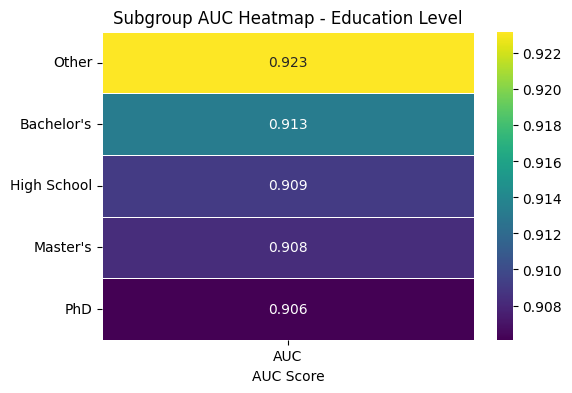

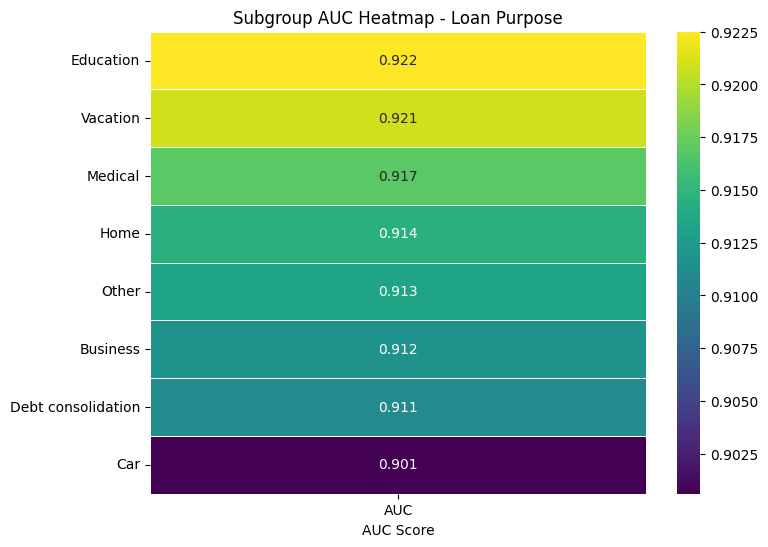

In [6]:
# ============================================================
#  HEATMAP VISUALIZATION FOR SUBGROUP AUC
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Convert subgroup results to DataFrame (filter out None values)
edu_heatmap_df = pd.DataFrame(
    sorted_edu, columns=['education_level', 'AUC']
).set_index('education_level')

purpose_heatmap_df = pd.DataFrame(
    sorted_purpose, columns=['loan_purpose', 'AUC']
).set_index('loan_purpose')

# -------------------------
# Heatmap - Education Level
# -------------------------
plt.figure(figsize=(6,4))
sns.heatmap(
    edu_heatmap_df,
    annot=True, cmap='viridis', linewidths=.5, fmt=".3f"
)
plt.title("Subgroup AUC Heatmap - Education Level")
plt.ylabel("")
plt.xlabel("AUC Score")
plt.show()

# -------------------------
# Heatmap - Loan Purpose
# -------------------------
plt.figure(figsize=(8,6))
sns.heatmap(
    purpose_heatmap_df,
    annot=True, cmap='viridis', linewidths=.5, fmt=".3f"
)
plt.title("Subgroup AUC Heatmap - Loan Purpose")
plt.ylabel("")
plt.xlabel("AUC Score")
plt.show()
